# Explorando la variable objetivo
Requiere `dataset_curvas_pliegues_random.csv` y `dataset_curvas_pliegues_TPE_N200.csv` en el mismo directorio.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import GroupKFold

## Metaconjuntos de datos

In [2]:
print("BÚSQUEDA ALEATORIA")
dataset_random = pd.read_csv('dataset_curvas_pliegues_random.csv')
dataset_random[:10]

BÚSQUEDA ALEATORIA


,task_id,X_shape,trial_id,fold_id,learning_rate,num_leaves,max_depth,min_child_samples,min_gain_to_split,feature_fraction,...,train_996,val_996,train_997,val_997,train_998,val_998,train_999,val_999,train_1000,val_1000
0,146820,"(4839, 5)",0,0,0.02369,96,8,64,0.23403,0.578,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,146820,"(4839, 5)",0,1,0.02369,96,8,64,0.23403,0.578,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,146820,"(4839, 5)",0,2,0.02369,96,8,64,0.23403,0.578,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,146820,"(4839, 5)",0,3,0.02369,96,8,64,0.23403,0.578,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,146820,"(4839, 5)",0,4,0.02369,96,8,64,0.23403,0.578,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,146820,"(4839, 5)",0,5,0.02369,96,8,64,0.23403,0.578,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,146820,"(4839, 5)",0,6,0.02369,96,8,64,0.23403,0.578,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,146820,"(4839, 5)",0,7,0.02369,96,8,64,0.23403,0.578,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,146820,"(4839, 5)",0,8,0.02369,96,8,64,0.23403,0.578,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,146820,"(4839, 5)",0,9,0.02369,96,8,64,0.23403,0.578,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
print("ALGORITMO TPE")
dataset_TPE = pd.read_csv('dataset_curvas_pliegues_TPE_N200.csv')
dataset_TPE[:10]

ALGORITMO TPE


,task_id,X_shape,trial_id,fold_id,learning_rate,num_leaves,max_depth,min_child_samples,min_gain_to_split,feature_fraction,...,train_996,val_996,train_997,val_997,train_998,val_998,train_999,val_999,train_1000,val_1000
0,146820,"(4839, 5)",0,0,0.02369,96,8,64,0.23403,0.578,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,146820,"(4839, 5)",0,1,0.02369,96,8,64,0.23403,0.578,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,146820,"(4839, 5)",0,2,0.02369,96,8,64,0.23403,0.578,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,146820,"(4839, 5)",0,3,0.02369,96,8,64,0.23403,0.578,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,146820,"(4839, 5)",0,4,0.02369,96,8,64,0.23403,0.578,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,146820,"(4839, 5)",0,5,0.02369,96,8,64,0.23403,0.578,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,146820,"(4839, 5)",0,6,0.02369,96,8,64,0.23403,0.578,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,146820,"(4839, 5)",0,7,0.02369,96,8,64,0.23403,0.578,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,146820,"(4839, 5)",0,8,0.02369,96,8,64,0.23403,0.578,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,146820,"(4839, 5)",0,9,0.02369,96,8,64,0.23403,0.578,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Distribución de la variable objetivo en cada estrategia de búsqueda

In [4]:
# Variable objetivo para cada estrategia de búsqueda
y_random = dataset_random['valid_logloss_fold']
y_TPE = dataset_TPE['valid_logloss_fold'] 

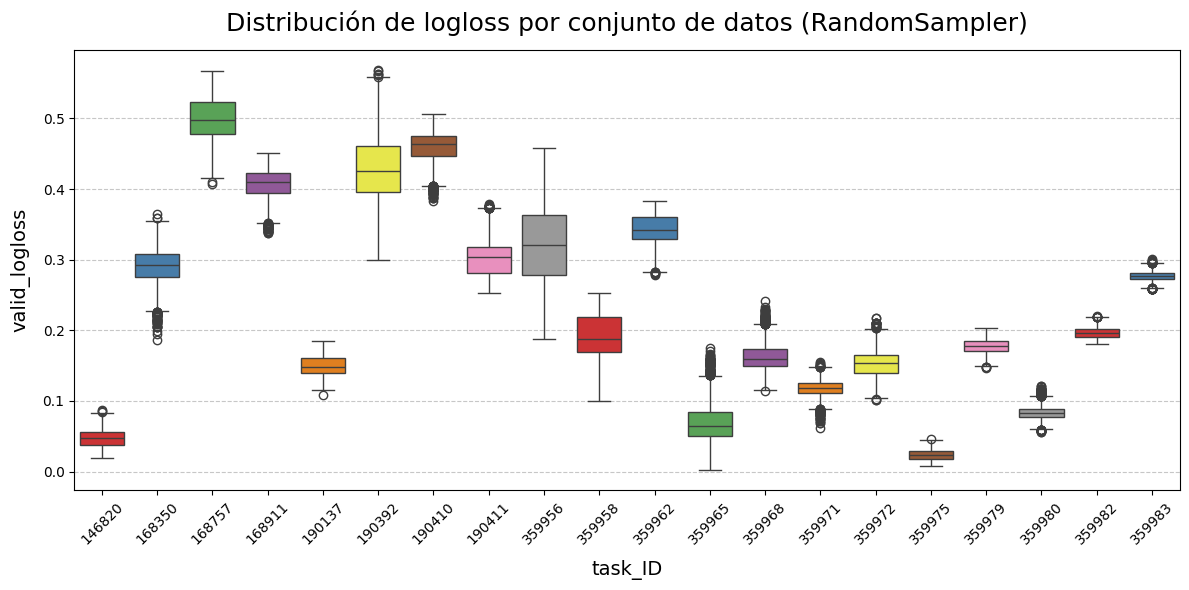

In [5]:
plt.figure(figsize=(12, 6))

sns.boxplot(
    x='task_id', 
    y='valid_logloss_fold', 
    data=dataset_random, 
    hue='task_id', 
    palette="Set1", 
    legend=False
)

plt.xticks(rotation=45)
plt.title('Distribución de logloss por conjunto de datos (RandomSampler)', fontsize=18, pad=14)
plt.xlabel('task_ID', fontsize=14, labelpad=9)
plt.ylabel('valid_logloss', fontsize=14, labelpad=9)

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

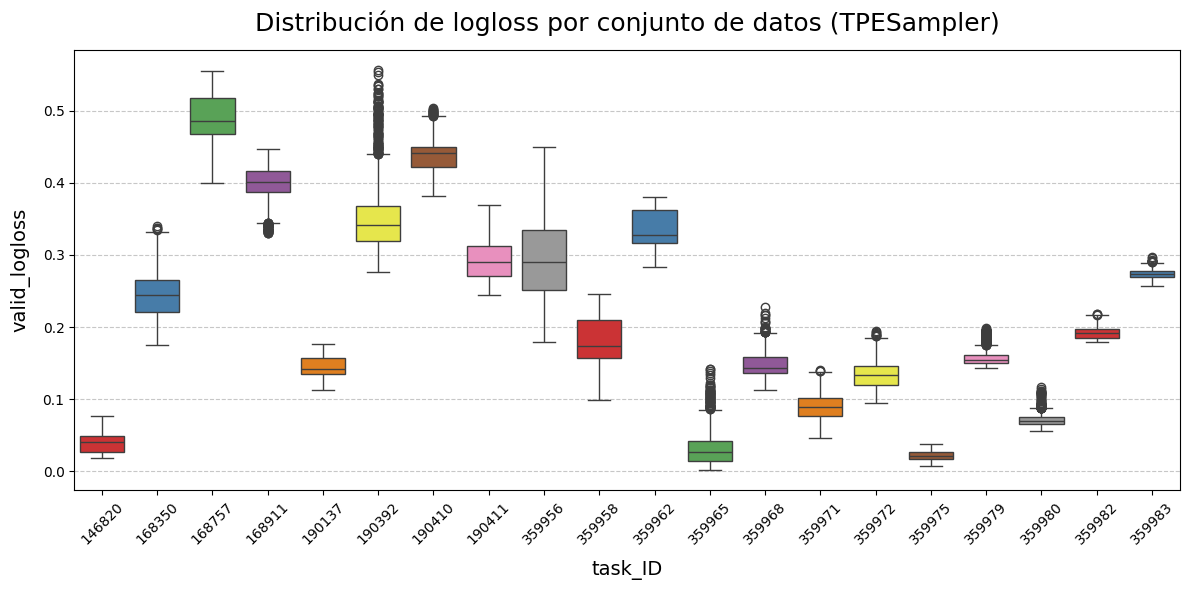

In [6]:
plt.figure(figsize=(12, 6))

sns.boxplot(
    x='task_id', 
    y='valid_logloss_fold', 
    data=dataset_TPE, 
    hue='task_id', 
    palette="Set1", 
    legend=False
)

plt.xticks(rotation=45)
plt.title('Distribución de logloss por conjunto de datos (TPESampler)', fontsize=18, pad=14)
plt.xlabel('task_ID', fontsize=14, labelpad=9)
plt.ylabel('valid_logloss', fontsize=14, labelpad=9)

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

## Validación cruzada por grupos

In [7]:
groups = dataset_random['task_id']
gkf = GroupKFold(n_splits=3, shuffle=True, random_state=42)

for i, (train_index, val_index) in enumerate(gkf.split(dataset_random, y_random, groups=groups)):
    grupos_train = np.unique(groups.iloc[train_index])
    grupos_val = np.unique(groups.iloc[val_index])
    
    n_filas_train = len(train_index)
    n_filas_val = len(val_index)
    
    print(f"--- Fold {i} ---")
    print(f"Tasks en VAL ({len(grupos_val)}): {grupos_val}")

--- Fold 0 ---
Tasks en VAL (7): [146820 168350 190392 359956 359965 359975 359980]
--- Fold 1 ---
Tasks en VAL (7): [168757 168911 359958 359971 359979 359982 359983]
--- Fold 2 ---
Tasks en VAL (6): [190137 190410 190411 359962 359968 359972]


In [8]:
# ID de los 20 conjuntos de datos
tasks = dataset_random['task_id'].unique()
tasks

array([146820, 168350, 168757, 168911, 190137, 190392, 190410, 190411,
       359956, 359958, 359962, 359965, 359968, 359971, 359972, 359975,
       359979, 359980, 359982, 359983])

## Evolución de los valores por Trial (para un Task y estrategia de búsqueda dados)

In [9]:
def graficar_logloss(df, task_id):
    # Filtrar por task_id y obtener valores reales promediados por trial
    filtro = df[df['task_id'] == task_id].copy()
    promedios_trial = filtro.groupby('trial_id')['valid_logloss_fold'].mean().sort_index()
    trial_ids = promedios_trial.index.tolist()

    # Graficar
    plt.figure(figsize=(12, 6))

    plt.plot(promedios_trial.values, marker='o', markersize=2, linestyle='-',
             linewidth=1, color='#2c3e50', label='Valor real')

    plt.title(f'Evolución de LogLoss por Trial (Task ID: {task_id})')
    plt.xlabel('Número de Trial')
    plt.ylabel('Media de LogLoss (10 folds)')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

### Búsqueda aleatoria

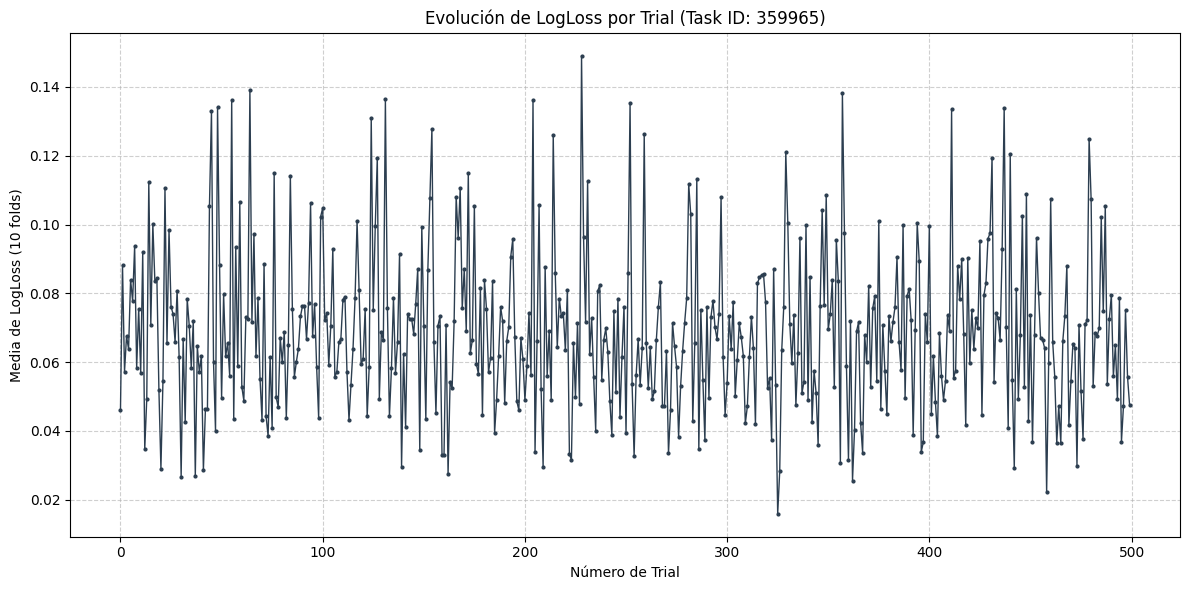

In [10]:
graficar_logloss(dataset_random, task_id=359965)

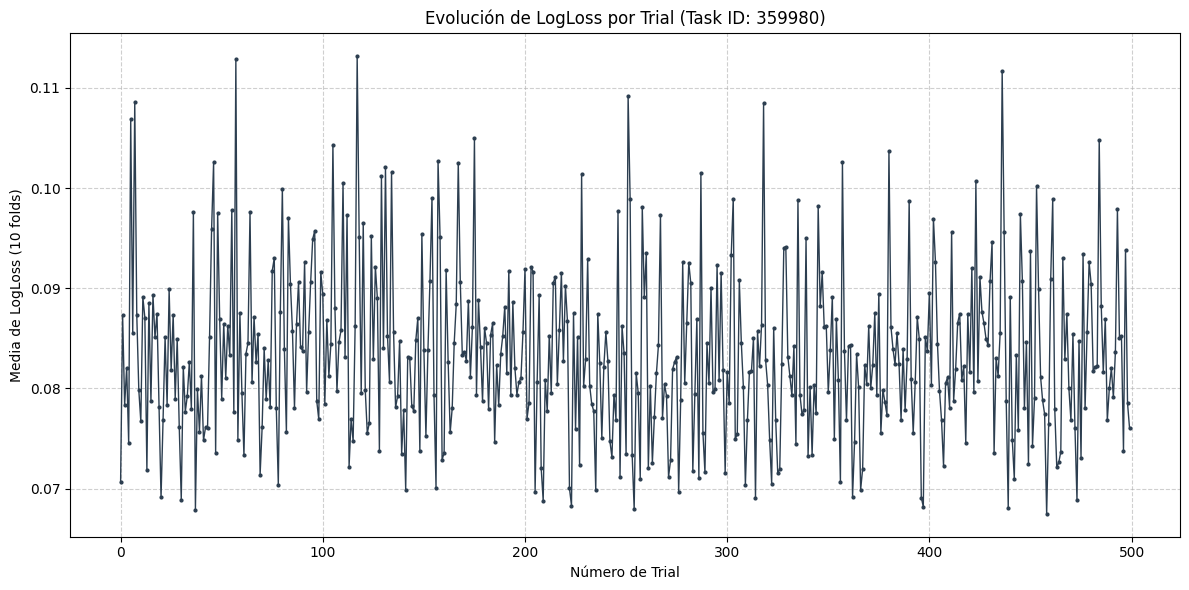

In [11]:
graficar_logloss(dataset_random, task_id=359980)

### Algoritmo TPE

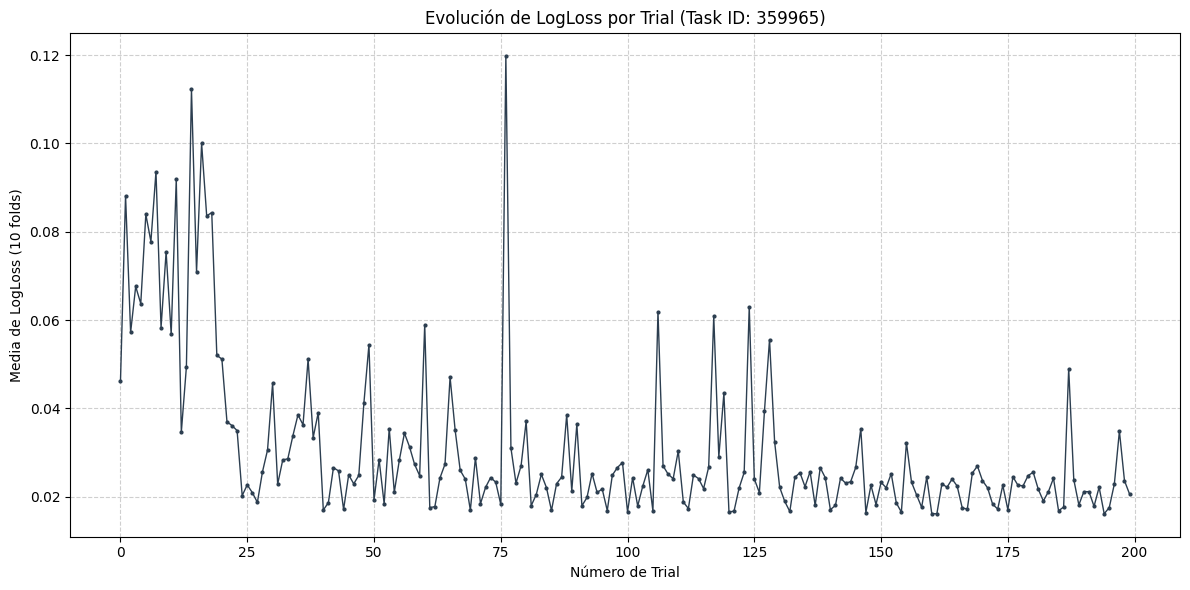

In [12]:
graficar_logloss(dataset_TPE, task_id=359965)

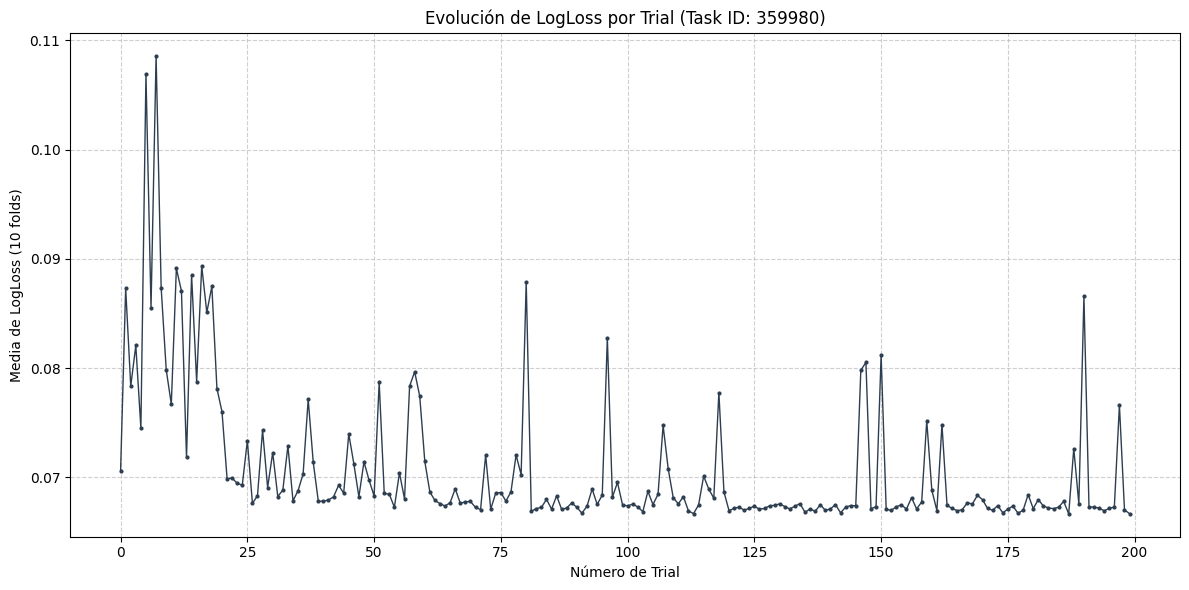

In [13]:
graficar_logloss(dataset_TPE, task_id=359980)